In [2]:
# Import packages
import numpy as np
import pandas as pd
import hdbscan
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn import datasets, linear_model, metrics
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Load data
df = pd.read_parquet('ready_data_2.parquet')
df.head()


,TransactionId,Lat,Lon,BuildingAge,UtilityArea,LotArea,QualityScore,CloseToBeach,EnergyPerformance,EnergyClass,...,MunicipalityMoveInFromCountyFrac,MunicipalityMoveOutToCountyFrac,MunicipalityMoveInFrac2yrChangeMean,MunicipalityMoveOutFrac2yrChangeMean,MunicipalityMoveInFromCountyFrac2yrChangeMean,MunicipalityMoveOutToCountyFrac2yrChangeMean,MunicipalityPopulationMeanDeviation,MedianRentMunicipality,MedianRentMunicipality2yrFracChangeMean,MedianRentMunicipalityMeanDeviation
0,10006194,56.742153,16.291778,48,143,480,36,0,60.0,0.125,...,0.025551,0.021314,0.001816,0.004082,0.000930,0.003437,4.373830,1155.0,0.091030,1.123790
1,10006232,57.278909,13.646019,54,120,750,32,0,114.0,0.125,...,0.010123,0.013869,-0.007777,0.006713,-0.001110,0.002518,1.843030,999.0,0.013451,0.972005
2,10006302,58.328009,15.103299,47,169,592,30,0,0.0,0.000,...,0.034871,0.028112,-0.003267,0.003278,-0.000932,0.000765,1.738860,1046.0,0.075010,1.017735
3,10006371,57.739437,14.122176,128,250,3311,30,0,88.0,0.375,...,0.013410,0.012764,-0.001062,0.001830,0.000457,0.000039,8.857676,1059.0,0.061507,1.030384
4,10006399,57.784585,16.146614,112,87,3406,28,0,101.0,0.500,...,0.006766,0.006466,-0.001024,-0.000181,0.000441,0.000045,2.279611,909.0,0.009151,0.884437


In [3]:
def remove_non_numbers(data):
    """Remove colums with data which are not numbers and return the matrix, without the columns, and the indexes of the removed rows."""
    del_data = data.copy()
    del_idx = {}

    # Removing all non int or float type features looping from the end.
    iterate = len(del_data[0,:])-1
    for i in range(iterate+1):
        if type(del_data[0,iterate-i]) != float and type(del_data[0,iterate-i]) != int:
            del_data = np.delete(del_data, obj=iterate-i, axis=1)
            del_idx[iterate-i] = iterate-i

    return del_data, del_idx


def normalize_feature(feature):
    """Min-max normalization. This retains the relative position of the data points."""
    return (feature-np.min(feature)) / (np.max(feature)-np.min(feature)), np.max(feature), np.min(feature)


def normalize(data, axis=1):
    """Using the normalize_feature function on an np.array along a chosen axis."""
    norm_data = np.zeros_like(data)
    normalization_variables = np.zeros((2, np.shape(data)[1])) # row 1: max value, row 2: min value

    for i in range(data.shape[axis]):
        norm_data[:,i], normalization_variables[0, i], normalization_variables[1, i] = normalize_feature(data[:,i])
    return norm_data, normalization_variables


def clustering(data, cluster_size=10, min_samples=10, distance_type='euclidean'):
    """Takes data, minimum cluster size, distance metric and returns an array of the data with an added column at index 0 with the cluster label and the number of clusters."""
    clusterer = hdbscan.HDBSCAN(min_cluster_size=cluster_size, min_samples=min_samples ,  metric=distance_type)    # , approx_min_span_tree=True, algorithm='boruvka_balltree'
    clusterer.fit(data)
    return clusterer.labels_.max()+1 , np.insert(data, 0, clusterer.labels_.flatten(), axis=1)


def center_of_mass(number_of_clusters, clusters):
    """Takes a number of clusters and a matrix with points declaring where the first column references which cluster to which the point belongs and
    the rest the coordinates of the point."""
    cluster_centers = np.zeros((number_of_clusters, len(clusters[0])))
    balancing_vector = np.zeros_like(cluster_centers)
    clusters[:,0] += 1
    for i in range(len(clusters[:,None])):
        if clusters[i,0] > 0:
            cluster_centers[int(clusters[i,0])-1] += clusters[i]
            balancing_vector[int(clusters[i,0])-1] += 1 # Keeps track of how many points are in each cluster.
    return cluster_centers / balancing_vector


def reduce_dimension(vector,clusters):
    """Takes a vector and a set of clusters and reduces the vectors dimension to the number of clusters using the clusters as a basis."""
    # Vector projection
    transformation_matrix = np.zeros([len(clusters), len(vector)])

    for i in clusters:
        transformation_matrix[i] = center_of_mass(clusters[i])

    reduced_vector = transformation_matrix * vector
    return reduced_vector


def get_cmap(n, name='hsv'):
    '''Returns a function that maps each index in 0, 1, ..., n-1 to a distinct 
    RGB color; the keyword argument name must be a standard mpl colormap name.'''
    return plt.cm.get_cmap(name, n)


def compare_Euclidean(reference, comparables, k=3):
    """Takes a reference point and a matrix of comparable points and returns the first column of the comparable points (ID) and
    the Euclidean distances sorted by distance from low to high."""

    sq_compare = np.square(comparables[:,1:] - reference[1:])
    sum_compare = np.sum(sq_compare, axis=1)
    Euc_compare = np.sqrt(sum_compare)
    Euc_compare = np.vstack((comparables[:, 0], Euc_compare)).T

    sorted_dis = Euc_compare[Euc_compare[:, 1].argsort()]   # Sort Euc_compare

    return sorted_dis[0:k, :]

def show_clusters_in_latlon(data, sorted_clusters, number_of_clusters, clusterspan, lat_index=2, lon_index=3):
    """Creates a 3D plot of the clusters and their center of mass."""

    fig = plt.figure(figsize = (10,10))
    ax = plt.axes()
    ax.grid()

    cmap = get_cmap((number_of_clusters+1)*2)

    for i in range(1,number_of_clusters+1):
        x1 = sorted_clusters[int(clusterspan[i]):int(clusterspan[i+1]), lat_index]
        y1 = sorted_clusters[int(clusterspan[i]):int(clusterspan[i+1]), lon_index]
        ax.scatter(x1, y1, c = cmap(i), s = 1)

    ax.set_title('Scatter Plot')

    # Set axes label
    ax.set_xlabel('x', labelpad=20)
    ax.set_ylabel('y', labelpad=20)

In [4]:
# Chaning to numpy array
def dataframe_to_numpy(dataframe):
    dataframe = dataframe.fillna(0)
    data = dataframe.to_numpy()


    data, removed_indices = remove_non_numbers(data)
    print("Removed indices:", removed_indices)



    data = data.astype(float) # Changing from type object to float so that numpy functions work properly.
    return data

# Transaction_ID = df.iloc[:, 0]
# Transaction_ID = Transaction_ID.to_numpy()
# Transaction_ID = Transaction_ID.astype(np.float64)
# print(f'ID0: {Transaction_ID}, type: ')




# df = df.drop("TransactionId", axis=1)

data = dataframe_to_numpy(df)

# Instead of using TransactionID just asssign each data point an integer using np.arange
ID = np.arange(np.shape(data)[0])

print(ID)

# Divide the data set into training and testing data
percent = 0.20  # Fraction used for testing
samples = int(np.shape(data)[0] * percent)

training_data, testing_data = train_test_split(data, test_size=samples)

samples_2 = int(np.shape(training_data)[0]*percent)
training_data, validation_data = train_test_split(training_data, test_size=samples_2, random_state=69)

print('X1 shape: ', training_data.shape)
print('X3 shape: ', validation_data.shape)
print('X2 shape: ', testing_data.shape)

Removed indices: {0: 0}
[    0     1     2 ... 91627 91628 91629]
X1 shape:  (58644, 164)
X3 shape:  (14660, 164)
X2 shape:  (18326, 164)


In [5]:
def create_clusterspan(sorted_clusters, number_of_clusters):
    clusterspan = np.zeros(number_of_clusters + 2)

    j = 0
    for i in range(len(sorted_clusters[:,0])-1):
        if sorted_clusters[i, 0] < sorted_clusters[i+1,0]:
            # print(sorted_clusters[i, 0])
            clusterspan[j+1] = i+1
            j += 1
    clusterspan[-1] = len(sorted_clusters[:,0])
    return clusterspan


# Normalizing the data
norm_data, normalize_variables = normalize(training_data[0:200, :])

In [6]:
print(norm_data)

[[0.78937403 0.21770579 0.48235294 ... 0.         0.20621547 0.        ]
 [0.96795716 0.36618133 0.30588235 ... 0.         0.20621547 0.        ]
 [0.56469337 0.23100134 0.28823529 ... 0.81377551 0.41536876 0.82043538]
 ...
 [0.89299833 0.48966592 0.25882353 ... 1.         0.5251205  0.97916837]
 [0.07740131 0.23858544 0.34705882 ... 0.82908163 0.21738367 0.85802613]
 [0.46061358 0.32674757 0.35294118 ... 0.83078231 0.2771558  0.79285723]]


In [7]:
# Improved Silhouette method

def cluster_silhouette(clusterdata, CS, cluster_index, CoM):
    current_cluster = clusterdata[int(CS[cluster_index]):int(CS[cluster_index+1]), :]
    n = np.shape(current_cluster)[0] # Data points in current cluster

    OCS = np.delete(CS, cluster_index+1)
    OCS[cluster_index+1:] -= n
    other_clusters = np.delete(clusterdata.copy(), np.s_[int(CS[cluster_index]):int(CS[cluster_index+1])], axis=0)

    
    dis_cur_cluster = 0
    NoOC = np.shape(OCS)[0]-1 # NoOC = number of other clusters
    dis_cluster = np.zeros(NoOC)
    dis_near_cluster = 0.0

    for j in range(0, n):
        ref_point = current_cluster[j, :]
        dis_cur_cluster += np.sum(compare_Euclidean(ref_point, current_cluster)[:, 1]) / n

        




        for l in range(0, NoOC):
            nearest_cluster = other_clusters[int(OCS[l]):int(OCS[l+1]), :]
            m = np.shape(nearest_cluster)[0] # Data points in nearest cluster
            dis_cluster[l] = np.sum(compare_Euclidean(ref_point, nearest_cluster)[:, 1]) / m
        dis_near_cluster += np.min(dis_cluster, axis=0)


    try:
        average_silhouette = (dis_near_cluster - dis_cur_cluster) / np.maximum(dis_near_cluster, dis_cur_cluster)
        return average_silhouette
    except FloatingPointError:
        print('Current cluster:', current_cluster, 'Dis near:', dis_near_cluster, 'Dis cur:', dis_cur_cluster)

    return 0.0

def Silhouette(SC, NoC, CoM, CS):
    # SC = sorted clusters, NoC = number of clusters, CoM = centers of mass, CS = clusterspan
    average_silhouette_clusters = np.zeros((NoC, 2))

    # Find nearest cluster
    for i in range(1, NoC+1):
        average_silhouette_clusters[i-1, :] = i, cluster_silhouette(SC, CS, i, CoM)
    
    average_overall_silhouette = np.sum(average_silhouette_clusters[:, 1]) / NoC
    return average_overall_silhouette, average_silhouette_clusters


def calculate_silhouette(data, start, end, step_size):

    max_iterations = (end-start) // step_size + 1
    Sil_mat = np.zeros((max_iterations, 3))
    # Sil_mat = np.zeros((data_points-2, 2))
    print(np.shape(data)[0])
    cluster_mat = np.zeros((np.shape(data)[0], max_iterations))

    for MCS in range(start, end+1, step_size): # range(2, data_points): # MCS = minimum cluster size  range(9, 11): # 
        index = (MCS-start)//step_size
        print('MCS:', MCS)
        number_of_clusters, clustered_data = clustering(data, cluster_size=MCS, min_samples=2)
        print(number_of_clusters)
        
        cluster_mat[:, index] = clustered_data[:, 0]
        
        if number_of_clusters < 2:
            Sil_mat[index] = MCS, 0, number_of_clusters
            continue
        sorted_clusters = clustered_data[clustered_data[:, 0].argsort()] # sorting the clustered data by cluster affiliation
        sorted_clusters[:,0] +=1

        clusterspan = create_clusterspan(sorted_clusters, number_of_clusters)
        print('Clusterspan', clusterspan)
        cspd = pd.DataFrame(clusterspan)
        cspd.to_csv('testcsv.csv')
        centers_of_mass = center_of_mass(number_of_clusters, clustered_data) # Kanske ta bort .copy() för bättre prestanda
        
        average_silhouette, cluster_silhouettes = Silhouette(sorted_clusters, number_of_clusters, centers_of_mass, clusterspan)
        print(f'Silhouette: {average_silhouette} \n Cluster silhouettes: {cluster_silhouettes}')
        Sil_mat[index] = MCS, average_silhouette, number_of_clusters
    print(Sil_mat)
    return Sil_mat, sorted_clusters, number_of_clusters, clusterspan, cluster_silhouettes, cluster_mat

In [8]:
Sil_mat, sorted_clusters, number_of_clusters, clusterspan, cluster_silhouettes, cluster_mat = calculate_silhouette(
                                                            norm_data, start = 2, end = 20, step_size = 2)

print(sorted_clusters)

cluster_mat_x = pd.DataFrame(cluster_mat)
cluster_mat_x.to_parquet('Results_clustering_1_260127.parquet')

200
MCS: 2
17
Clusterspan [  0. 135. 137. 139. 141. 144. 146. 153. 156. 160. 165. 171. 177. 180.
 183. 185. 190. 197. 200.]
Silhouette: -0.9396470055594554 
 Cluster silhouettes: [[ 1.         -0.95471506]
 [ 2.         -0.94995833]
 [ 3.         -0.95432935]
 [ 4.         -0.9526299 ]
 [ 5.         -0.95379853]
 [ 6.         -0.90681559]
 [ 7.         -0.96711856]
 [ 8.         -0.92024251]
 [ 9.         -0.92606456]
 [10.         -0.92423465]
 [11.         -0.92270775]
 [12.         -0.96517843]
 [13.         -0.95419642]
 [14.         -0.9419387 ]
 [15.         -0.9198146 ]
 [16.         -0.90166917]
 [17.         -0.95858699]]
MCS: 4
2
Clusterspan [  0.  84. 168. 200.]
Silhouette: 0.14014734289160824 
 Cluster silhouettes: [[ 1.          0.50223829]
 [ 2.         -0.2219436 ]]
MCS: 6
2
Clusterspan [  0.  84. 168. 200.]
Silhouette: 0.14014734289160824 
 Cluster silhouettes: [[ 1.          0.50223829]
 [ 2.         -0.2219436 ]]
MCS: 8
2
Clusterspan [  0.  84. 168. 200.]
Silhouette: 

/var/folders/s9/fpc42dw53pgc33tc9cwdpsbh0000gp/T/ipykernel_2908/2938172398.py:66: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  return plt.cm.get_cmap(name, n)
/var/folders/s9/fpc42dw53pgc33tc9cwdpsbh0000gp/T/ipykernel_2908/2938172398.py:94: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(x1, y1, c = cmap(i), s = 1)


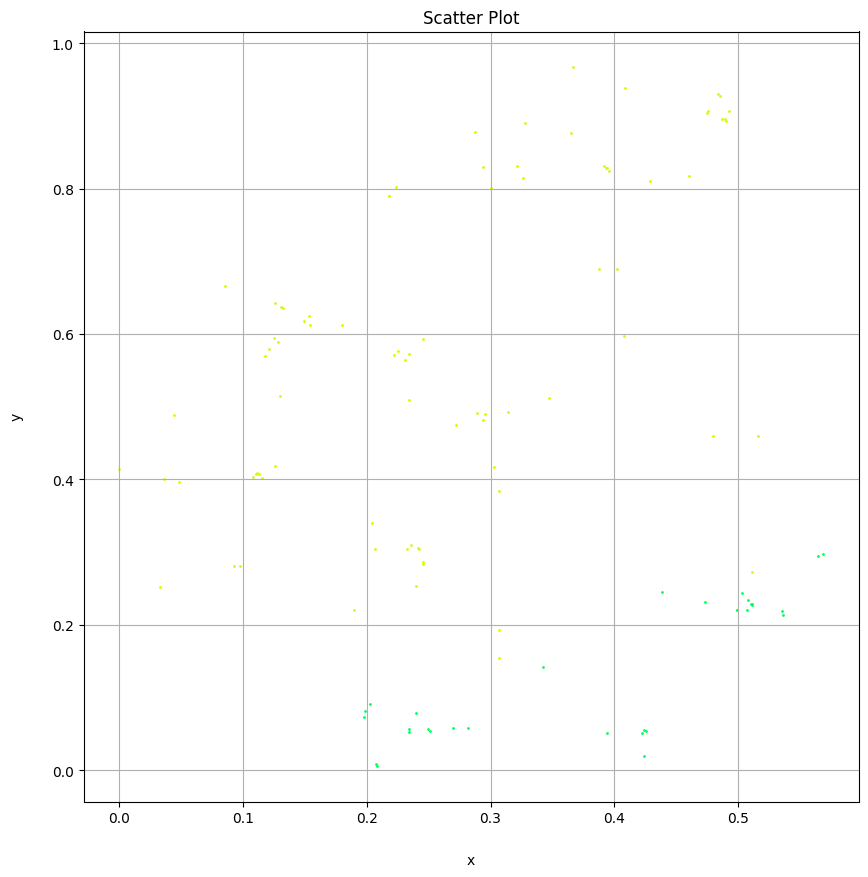

In [9]:
show_clusters_in_latlon(norm_data, sorted_clusters, number_of_clusters, clusterspan,2, 1)

In [10]:
# Improved Silhouette method

def cluster_silhouette(clusterdata, CS, cluster_index):
    current_cluster = clusterdata[int(CS[cluster_index]):int(CS[cluster_index+1]), :]
    n = np.shape(current_cluster)[0] # Data points in current cluster

    OCS = np.delete(CS, cluster_index+1)
    OCS[cluster_index+1:] -= n
    other_clusters = np.delete(clusterdata.copy(), np.s_[int(CS[cluster_index]):int(CS[cluster_index+1])], axis=0)

    
    dis_cur_cluster = 0
    NoOC = np.shape(OCS)[0]-1 # NoOC = number of other clusters
    dis_cluster = np.zeros(NoOC)
    dis_near_cluster = 0.0

    for j in range(0, n):
        ref_point = current_cluster[j, :]
        dis_cur_cluster += np.sum(compare_Euclidean(ref_point, current_cluster)[:, 1]) / n
        
        for l in range(0, NoOC):
            nearest_cluster = other_clusters[int(OCS[l]):int(OCS[l+1]), :]
            m = np.shape(nearest_cluster)[0] # Data points in nearest cluster
            dis_cluster[l] = np.sum(compare_Euclidean(ref_point, nearest_cluster)[:, 1]) / m
        dis_near_cluster += np.min(dis_cluster, axis=0)


    try:
        average_silhouette = (dis_near_cluster - dis_cur_cluster) / np.maximum(dis_near_cluster, dis_cur_cluster)
        return average_silhouette
    except FloatingPointError:
        print('Current cluster:', current_cluster, 'Dis near:', dis_near_cluster, 'Dis cur:', dis_cur_cluster)

    return 0.0

def Silhouette(SC, NoC, CS):
    # SC = sorted clusters, NoC = number of clusters, CoM = centers of mass, CS = clusterspan
    average_silhouette_clusters = np.zeros((NoC, 2))

    # Find nearest cluster
    for i in range(1, NoC+1):
        average_silhouette_clusters[i-1, :] = i, cluster_silhouette(SC, CS, i)
    
    average_overall_silhouette = np.sum(average_silhouette_clusters[:, 1]) / NoC
    return average_overall_silhouette, average_silhouette_clusters


def calculate_silhouette(data, start, end, step_size):

    max_iterations = (end-start) // step_size + 1
    Sil_mat = np.zeros((max_iterations, 3))
    # Sil_mat = np.zeros((data_points-2, 2))
    print(np.shape(data)[0])
    cluster_mat = np.zeros((np.shape(data)[0], max_iterations))

    for MCS in range(start, end+1, step_size): # range(2, data_points): # MCS = minimum cluster size  range(9, 11): # 
        index = (MCS-start)//step_size
        print('MCS:', MCS)
        number_of_clusters, clustered_data = clustering(data, cluster_size=MCS, min_samples=2)
        print(number_of_clusters)
        
        cluster_mat[:, index] = clustered_data[:, 0]
        
        if number_of_clusters < 2:
            Sil_mat[index] = MCS, 0, number_of_clusters
            continue
        sorted_clusters = clustered_data[clustered_data[:, 0].argsort()] # sorting the clustered data by cluster affiliation
        sorted_clusters[:,0] +=1

        clusterspan = create_clusterspan(sorted_clusters, number_of_clusters)
        print('Clusterspan', clusterspan)
        cspd = pd.DataFrame(clusterspan)
        cspd.to_csv('testcsv.csv')
        centers_of_mass = center_of_mass(number_of_clusters, clustered_data) # Kanske ta bort .copy() för bättre prestanda
        
        average_silhouette, cluster_silhouettes = Silhouette(sorted_clusters, number_of_clusters, clusterspan)
        print(f'Silhouette: {average_silhouette} \n Cluster silhouettes: {cluster_silhouettes}')
        Sil_mat[index] = MCS, average_silhouette, number_of_clusters
    print(Sil_mat)
    return Sil_mat, sorted_clusters, number_of_clusters, clusterspan, cluster_silhouettes, cluster_mat

In [11]:
Sil_mat, sorted_clusters, number_of_clusters, clusterspan, cluster_silhouettes, cluster_mat = calculate_silhouette(
                                                            norm_data, start = 2, end = 20, step_size = 2)

print(sorted_clusters)

cluster_mat_x = pd.DataFrame(cluster_mat)
cluster_mat_x.to_parquet('Results_clustering_1_260127.parquet')

200
MCS: 2
17
Clusterspan [  0. 135. 137. 139. 141. 144. 146. 153. 156. 160. 165. 171. 177. 180.
 183. 185. 190. 197. 200.]
Silhouette: -0.9396470055594554 
 Cluster silhouettes: [[ 1.         -0.95471506]
 [ 2.         -0.94995833]
 [ 3.         -0.95432935]
 [ 4.         -0.9526299 ]
 [ 5.         -0.95379853]
 [ 6.         -0.90681559]
 [ 7.         -0.96711856]
 [ 8.         -0.92024251]
 [ 9.         -0.92606456]
 [10.         -0.92423465]
 [11.         -0.92270775]
 [12.         -0.96517843]
 [13.         -0.95419642]
 [14.         -0.9419387 ]
 [15.         -0.9198146 ]
 [16.         -0.90166917]
 [17.         -0.95858699]]
MCS: 4
2
Clusterspan [  0.  84. 168. 200.]
Silhouette: 0.14014734289160824 
 Cluster silhouettes: [[ 1.          0.50223829]
 [ 2.         -0.2219436 ]]
MCS: 6
2
Clusterspan [  0.  84. 168. 200.]
Silhouette: 0.14014734289160824 
 Cluster silhouettes: [[ 1.          0.50223829]
 [ 2.         -0.2219436 ]]
MCS: 8
2
Clusterspan [  0.  84. 168. 200.]
Silhouette: 

In [12]:
a = np.array([[0, 1, 2],

              [0, 2, 4],

              [0, 3, 6]])
print(a, np.shape(a))
b = np.where(a != 2, a, a+10)
print(b, np.shape(b[0]))

[[0 1 2]
 [0 2 4]
 [0 3 6]] (3, 3)
[[ 0  1 12]
 [ 0 12  4]
 [ 0  3  6]] (3,)


In [13]:
# a = np.arange(10)
a = np.array([[0, 1, 2],

              [0, 2, 4],

              [0, 3, 6]])
print(a)
# a[7] = 2
b = a[np.where(a[1] < 3)]
print(b, np.shape(b))

[[0 1 2]
 [0 2 4]
 [0 3 6]]
[[0 1 2]
 [0 2 4]] (2, 3)


In [14]:

def create_clusterspan(sorted_clusters, number_of_clusters):
    clusterspan = np.zeros(number_of_clusters+2)

    for i in range(0, number_of_clusters+1):
        print(f'shape: {np.shape(sorted_clusters[np.where(sorted_clusters[:,0] == i)])[0]}')
        clusterspan[i+1] = clusterspan[i] + np.shape(sorted_clusters[np.where(sorted_clusters[:,0] == i)])[0]

    clusterspan[-1] = np.shape(sorted_clusters)[0]
    return clusterspan

def cluster_silhouette(clusterdata, CS, cluster_index):
    current_cluster = clusterdata[int(CS[cluster_index]):int(CS[cluster_index+1]), :]
    n = np.shape(current_cluster)[0] # Data points in current cluster
    
    OCS = np.delete(CS, cluster_index+1)
    OCS[cluster_index+1:] -= n
    other_clusters = np.delete(clusterdata.copy(), np.s_[int(CS[cluster_index]):int(CS[cluster_index+1])], axis=0)

    
    dis_cur_cluster = 0
    NoOC = np.shape(OCS)[0]-2 # NoOC = number of other clusters
    dis_cluster = np.zeros(NoOC)
    dis_near_cluster = 0.0

    for j in range(0, n):
        ref_point = current_cluster[j, :]
        dis_cur_cluster += np.sum(compare_Euclidean(ref_point, current_cluster)[:, 1]) / n
        
        for l in range(1, NoOC+1):
            nearest_cluster = other_clusters[int(OCS[l]):int(OCS[l+1]), :]
            m = np.shape(nearest_cluster)[0] # Data points in nearest cluster
            if m >0:
                dis_cluster[l-1] = np.sum(compare_Euclidean(ref_point, nearest_cluster)[:, 1]) / m
            else:
                print(f'NoOC: {NoOC}, rows: {m}, cluster: {nearest_cluster}, clusterspan: {CS, OCS}')
                # print(f'sorted_clusters {sorted_clusters}, points: {np.shape(sorted_clusters)[0]}')
                cluster_mat_x = pd.DataFrame(sorted_clusters)
                cluster_mat_x.to_parquet(f'sorted_clusters_260131.parquet')
                break
        # print(f'dis_cluster: {dis_cluster}')
        dis_near_cluster += np.min(dis_cluster, axis=0)


    try:
        average_silhouette = (dis_near_cluster - dis_cur_cluster) / np.maximum(dis_near_cluster, dis_cur_cluster)
        return average_silhouette
    except FloatingPointError:
        print('Current cluster:', current_cluster, 'Dis near:', dis_near_cluster, 'Dis cur:', dis_cur_cluster)

    return 0.0

def Silhouette(SC, NoC, CS):
    # SC = sorted clusters, NoC = number of clusters, CoM = centers of mass, CS = clusterspan
    average_silhouette_clusters = np.zeros((NoC, 2))

    # Find nearest cluster
    for i in range(1, NoC+1):
        average_silhouette_clusters[i-1, :] = i, cluster_silhouette(SC, CS, i)
    
    average_overall_silhouette = np.sum(average_silhouette_clusters[:, 1]) / NoC
    return average_overall_silhouette, average_silhouette_clusters


def optimal_cluster_size(data, max_MCS = 9000, min_MCS = 2000, step_size = 1000, max_recursion = 7, recursion = 0, first_calc=0):
    print('recursion:', recursion)
    
    backup = min_MCS 
    
    if first_calc !=0:
        min_MCS = first_calc
    
    max_iterations = (max_MCS-min_MCS) // step_size + 1
    Sil_mat = np.zeros((max_iterations, 3))
    # Sil_mat = np.zeros((data_points-2, 2))
    # print(np.shape(data)[0])
    cluster_mat = np.zeros((np.shape(data)[0], np.shape(data)[1]+1, max_iterations)) # For saving results

    best_silhouette = -1
    best_index = 0
    best_cluster_index = 0

    for MCS in range(min_MCS, max_MCS+1, step_size): # range(2, data_points): # MCS = minimum cluster size  range(9, 11): # 
        index = (MCS-min_MCS)//step_size
        # print('MCS:', MCS)
        number_of_clusters, clustered_data = clustering(data, cluster_size=MCS, min_samples=2)
        # print(number_of_clusters)
        clustered_data[:, 0] +=1
        cluster_mat[:,:, index] = clustered_data

        if number_of_clusters < 2:
            Sil_mat[index] = MCS, 0, number_of_clusters
            print(f'{MCS} skipped because number of clusters < 2.')
            continue
        sorted_clusters = clustered_data[clustered_data[:, 0].argsort()] # sorting the clustered data by cluster affiliation
        # sorted_clusters[:,0] +=1

        clusterspan = create_clusterspan(sorted_clusters, number_of_clusters)
        # print('Clusterspan', clusterspan)
        # cspd = pd.DataFrame(clusterspan)
        # cspd.to_csv('testcsv.csv')
        # centers_of_mass = center_of_mass(number_of_clusters, clustered_data) # Kanske ta bort .copy() för bättre prestanda
        if clusterspan[2] == 0:
            print(f'sorted_clusters {sorted_clusters}, points: {np.shape(clustered_data)[0]}')
            # cluster_mat_x = pd.DataFrame(sorted_clusters)
            # cluster_mat_x.to_parquet(f'sorted_clusters_260131.parquet')
        print(f'clusterspan: {clusterspan}, number of clusters {number_of_clusters}')
        average_silhouette, cluster_silhouettes = Silhouette(sorted_clusters, number_of_clusters, clusterspan)
        # print(cluster_silhouettes, 'argmax', np.argmax(cluster_silhouettes[:,1]))
        if average_silhouette > best_silhouette:
            best_silhouette, best_index, best_cluster_index = average_silhouette, index, np.argmax(cluster_silhouettes[:, 1])

        print(f'MCS: {MCS}, Silhouette: {average_silhouette} \n Cluster silhouettes: {cluster_silhouettes}')
        Sil_mat[index] = MCS, average_silhouette, number_of_clusters
    # print(Sil_mat)
    min_MCS = backup
    # b = a[np.where(a[1] < 3)]
    print(f'Best silhouette: {best_silhouette}, Best index: {best_index}, Best cluster index: {best_cluster_index}')
    cluster_mat_best = cluster_mat[:, :, best_index]
    print('NOC:', np.max(cluster_mat_best[:,0]))
    # print(cluster_mat_best)
    best_cluster = cluster_mat_best[np.where(cluster_mat_best[:, 0] == best_cluster_index)]
    # print(np.shape(best_cluster))
    remaining_clusters = cluster_mat_best[np.where(cluster_mat_best[:, 0] != best_cluster_index)]
    size_bc = np.shape(best_cluster)[0]
    # print(np.min([min_MCS, int(size_bc/2)]))
    size_rc = np.shape(remaining_clusters)[0]
    # print(np.shape(remaining_clusters))
    if recursion < max_recursion and size_bc > 0 and size_rc > 0:
        if  size_bc > min_MCS and int(size_bc/2) > 0:
            partition_1 = optimal_cluster_size(best_cluster[:, 1:], np.min([max_MCS, size_bc-2]), np.min([min_MCS, int(size_bc/2)]), max_recursion=max_recursion, recursion=recursion+1)
        else:
            partition_1 = best_cluster

        if  size_rc > min_MCS and int(size_rc/2) > 0:
            partition_2 = optimal_cluster_size(remaining_clusters[:, 1:], np.min([max_MCS, size_rc-2]), np.min([min_MCS, int(size_rc/2)]), max_recursion=max_recursion, recursion=recursion+1)
        else:
            partition_2 = remaining_clusters
    else:
        partition_1 = best_cluster
        partition_2 = remaining_clusters

    # print('2', partition_2)
    partition_3 = partition_2[np.where(partition_2[:, 0] == 0)]
    partition_2 = partition_2[np.where(partition_2[:, 0] != 0)]

    if size_bc > 0:
        partition_2[:, 0] += np.max(partition_1[:,0]) # , partition_2[:, 0], partition_2[:, 0] + np.max(partition_1[:,0]))
    
        
    # print('max', np.max(partition_1[:,0]), 'remaining', remaining_clusters.shape)
    # print('partition', partition_1.shape, partition_2.shape)
    

    return np.vstack((partition_1, partition_2, partition_3))

# Normalizing the data
norm_data, normalization_variables = normalize(training_data)
print(np.shape(norm_data))

optimal_clustering = optimal_cluster_size(norm_data, 20, 4, 2)
print(optimal_clustering)


(58644, 164)
recursion: 0


: 

: 

shape: 53
shape: 4
shape: 25
shape: 7
shape: 106
shape: 5
[[ 1.         -0.94979051]
 [ 2.         -0.62521933]
 [ 3.         -0.88204066]
 [ 4.          0.89454989]
 [ 5.         -0.90987198]] argmax 3


/var/folders/s9/fpc42dw53pgc33tc9cwdpsbh0000gp/T/ipykernel_98215/2938172398.py:66: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  return plt.cm.get_cmap(name, n)
/var/folders/s9/fpc42dw53pgc33tc9cwdpsbh0000gp/T/ipykernel_98215/2938172398.py:94: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(x1, y1, c = cmap(i), s = 1)


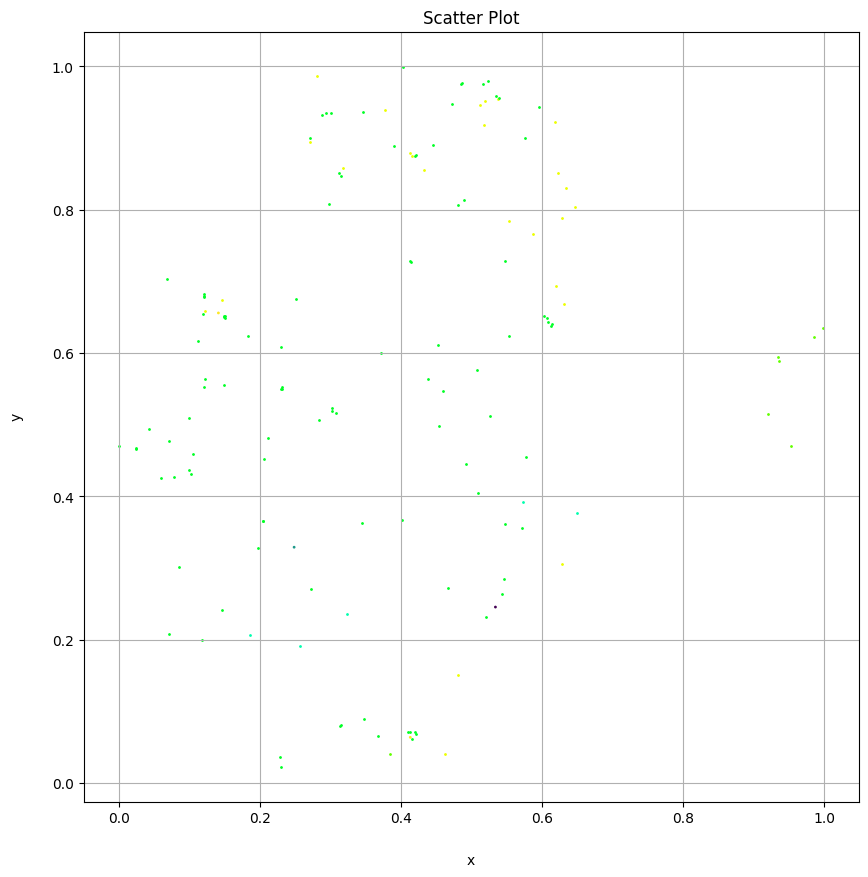

In [246]:
sorted_clusters = optimal_clustering[optimal_clustering[:, 0].argsort()] # sorting the clustered data by cluster affiliation
number_of_clusters = int(np.max(sorted_clusters[:,0]))
clusterspan = create_clusterspan(sorted_clusters, number_of_clusters)
average_silhouette, cluster_silhouettes = Silhouette(sorted_clusters, number_of_clusters, clusterspan)
print(cluster_silhouettes, 'argmax', np.argmax(cluster_silhouettes[:,1]))
show_clusters_in_latlon(norm_data, sorted_clusters, number_of_clusters, clusterspan,2, 1)

In [210]:
cluster_mat_x = pd.DataFrame(optimal_clustering)
cluster_mat_x.to_parquet(f'Final_clustering_test.parquet')

In [ ]:
def optimal_cluster_partition(data, checked_matrix, index_tuple, tuple_parent, max_MCS = 9000, min_MCS = 2000, step_size = 1000, max_recursion = 7, recursion = 0, first_calc=0):
    print('recursion:', recursion)
    
    backup = min_MCS 
    
    if first_calc !=0:
        min_MCS = first_calc
    
    max_iterations = (max_MCS-min_MCS) // step_size + 1
    Sil_mat = np.zeros((max_iterations, 3))
    cluster_mat = np.zeros((np.shape(data)[0], np.shape(data)[1]+1, max_iterations)) # For saving results

    best_silhouette = -1
    best_index = 0
    best_cluster_index = 0

    for MCS in range(min_MCS, max_MCS+1, step_size): # range(2, data_points): # MCS = minimum cluster size  range(9, 11): # 
        index = (MCS-min_MCS)//step_size
        print('MCS:', MCS)
        number_of_clusters, clustered_data = clustering(data, cluster_size=MCS, min_samples=2)
        clustered_data[:, 0] +=1
        cluster_mat[:,:, index] = clustered_data

        if number_of_clusters < 2:
            Sil_mat[index] = MCS, 0, number_of_clusters
            print(f'{MCS} skipped because number of clusters < 2.')
            continue
        sorted_clusters = clustered_data[clustered_data[:, 0].argsort()] # sorting the clustered data by cluster affiliation

        clusterspan = create_clusterspan(sorted_clusters, number_of_clusters)
        
        print(f'clusterspan: {clusterspan}, number of clusters {number_of_clusters}')
        average_silhouette, cluster_silhouettes = Silhouette(sorted_clusters, number_of_clusters, clusterspan)

        if average_silhouette > best_silhouette:
            best_silhouette, best_index, best_cluster_index = average_silhouette, index, np.argmax(cluster_silhouettes[:, 1])

        print(f'MCS: {MCS}, Silhouette: {average_silhouette} \n Cluster silhouettes: {cluster_silhouettes}')
        Sil_mat[index] = MCS, average_silhouette, number_of_clusters

    min_MCS = backup

    print(f'Best silhouette: {best_silhouette}, Best index: {best_index}, Best cluster index: {best_cluster_index}')
    cluster_mat_best = cluster_mat[:, :, best_index]



    print('NOC:', np.max(cluster_mat_best[:,0]))
    best_cluster = cluster_mat_best[np.where(cluster_mat_best[:, 0] == best_cluster_index)]
    remaining_clusters = cluster_mat_best[np.where(cluster_mat_best[:, 0] != best_cluster_index)]
    size_bc = np.shape(best_cluster)[0]
    size_rc = np.shape(remaining_clusters)[0]

    if recursion < max_recursion and size_bc > 0 and size_rc > 0:
        if  size_bc > min_MCS and int(size_bc/2) > 0:
            partition_1 = optimal_cluster_size(best_cluster[:, 1:], np.min([max_MCS, size_bc-2]), np.min([min_MCS, int(size_bc/2)]), max_recursion=max_recursion, recursion=recursion+1)
        else:
            partition_1 = best_cluster

        if  size_rc > min_MCS and int(size_rc/2) > 0:
            partition_2 = optimal_cluster_size(remaining_clusters[:, 1:], np.min([max_MCS, size_rc-2]), np.min([min_MCS, int(size_rc/2)]), max_recursion=max_recursion, recursion=recursion+1)
        else:
            partition_2 = remaining_clusters
    else:
        partition_1 = best_cluster
        partition_2 = remaining_clusters

    partition_3 = partition_2[np.where(partition_2[:, 0] == 0)]
    partition_2 = partition_2[np.where(partition_2[:, 0] != 0)]

    if size_bc > 0:
        partition_2[:, 0] += np.max(partition_1[:,0]) # , partition_2[:, 0], partition_2[:, 0] + np.max(partition_1[:,0]))
    
    return np.vstack((partition_1, partition_2, partition_3))

def assemble_partitions(checked_matrix, index_tuple):
    """index_tuple = (rows, columns) where the columns are the recursion number and the rows for each column are
      the possible partitions of the previous recursions data."""

    if recursion < max_recursion and size_bc > 0 and size_rc > 0:
        if  size_bc > min_MCS and int(size_bc/2) > 0:
            partition_1 = assemble_partitions(checked_matrix, )
        else:
            partition_1 = best_cluster

        if  size_rc > min_MCS and int(size_rc/2) > 0:
            partition_2 = optimal_cluster_size(remaining_clusters[:, 1:], np.min([max_MCS, size_rc-2]), np.min([min_MCS, int(size_rc/2)]), max_recursion=max_recursion, recursion=recursion+1)
        else:
            partition_2 = remaining_clusters
    else:
        partition_1 = best_cluster
        partition_2 = remaining_clusters

    # print('2', partition_2)
    partition_3 = partition_2[np.where(partition_2[:, 0] == 0)]
    partition_2 = partition_2[np.where(partition_2[:, 0] != 0)]

    if size_bc > 0:
        partition_2[:, 0] += np.max(partition_1[:,0]) # , partition_2[:, 0], partition_2[:, 0] + np.max(partition_1[:,0]))
    
    return np.vstack((partition_1, partition_2, partition_3))

def start_tuple(checked_matrix, index_tuple):
    i, j = index_tuple
    new_index_tuple = (0,0)
    finished_state_1 = False
    finished_state_2 = False

    if checked_matrix[i,j] == 1:
        new_tuple_1, finished_state_1 = start_tuple(checked_matrix, (2*i, j+1))
        new_tuple_2, finished_state_2 = start_tuple(checked_matrix, (2*i+1, j+1))

    if checked_matrix[i,j] == 2:
        return (i,j), False
    
    if checked_matrix[i,j] == 0:
        return  (int(i/2), j-1), True
    
    if finished_state_1 == True:
        return new_tuple_1
    else:
        return new_tuple_2

    
    
    partitions, recursions = np.shape(checked_matrix)
    movement_mat = checked_matrix
    
    sp = 0

    for column in range(recursions-1, -1, -1):
        for row in range(sp, partitions):
            if checked_matrix[row, column] == 2:
                sp = row
            

    return index_tuple

max_recursions = 7
checked_matrix = np.zeros((2**max_recursions, max_recursions))